<h1 style="text-align:center; color:green; font-size:48px;">
OEMOF TUTORIAL
</h1>

### Support functions

In [1]:
# Levelized Cost of Heat

def LCOH(invest_cost, operation_cost, heat_produced, revenue=0, i=0.05, n=20):
    pvf = ((1 + i) ** n - 1) / ((1 + i) ** n * i)

    return (invest_cost + pvf * (operation_cost - revenue)) / (
        pvf * heat_produced
    )
    
# Equivalent Periodic Cost

def epc(invest_cost, i=0.05, n=20):
    af = (i * (1 + i) ** n) / ((1 + i) ** n - 1)

    return invest_cost * af

# Import libraries

In [2]:
import os
import warnings
import logging
import pandas as pd
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing, Investment, NonConvex)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph

# Example

<img src="Example_OEMOF.png" width="40%">

## 1.1 Create the energy system

In [3]:
# read the input data file
filename = r"OEMOF_files/Example_1.csv"
data = pd.read_csv(filename)

# specifying the solver
solver = "cbc"
solver_verbose = False

# Create energy system
datetimeindex = pd.date_range(
    start='2022-01-01 00:00',
    periods=len(data),  # 8760 matches your data
    freq='h'
)
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)


# Add components to the energy system

# Buses - internal_elec_bus representing the electricity generated only by both CHPs
electrical_bus = Bus(label="electrical_bus") # Electricity bus (external grid)
thermal_bus = Bus(label="thermal_bus") # Heating bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biomass_bus = Bus(label="biomass_bus") # Biomass fuel bus
internal_elec_bus = Bus(label="internal_elec_bus") # Electricity from internal generation (NG and biomass CHPs)

import pandas as pd
from pathlib import Path

# Load the CSV and extract the losses column
csv_path = Path("Outputs") / "STEP_2.results_edges.csv"
absolute_losses = pd.read_csv(csv_path)["losses"]
total_absolute_losses = absolute_losses.sum()
print("Total absolute losses (kW):", round(total_absolute_losses, 2))

energysystem.add(electrical_bus, thermal_bus, gas_bus, biomass_bus, internal_elec_bus)



# Thermal demand (sink) considering the absolute losses
load_kW_nolosses = data["thermal_demand"]
load_kW = data["thermal_demand"] + total_absolute_losses
print("peak thermal demand (kW):", round(load_kW_nolosses.max(), 2))
print("peak thermal demand considering losses (kW):", round(load_kW.max(), 2))
peak = load_kW.max()
energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value=peak,
            fix=load_kW / peak  # Use load_kW (with losses) instead of data["thermal_demand"]
        )},
    )
)

# Excess electricity sink (only external grid)
energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={electrical_bus: Flow(
            variable_costs=data["electricity_price"]/1000 * -1,
            nominal_value=1e10          
        )}
    )
)

# Excess thermal sink (thermal surplus)
energysystem.add(
    Sink(
        label="excess_thermal",
        inputs={thermal_bus: Flow(
            nominal_value=1e10,       
            variable_costs=0       # INCREASE to penalize the excess heat
        )}
    )
)

# Sink for excess internal electricity (if the CHPs produce more than needed)
energysystem.add(
    Sink(
        label="excess_internal_electricity",
        inputs={internal_elec_bus: Flow(  
            nominal_value=1e10
        )}
    )
)




# Gas source with cost from gas
energysystem.add(
    Source(label="natural_gas",outputs={gas_bus: Flow()}) # costs defined in the converters
)

# Grid electricity source
energysystem.add(
    Source(label="electricity_grid",outputs={electrical_bus: Flow(variable_costs=data["electricity_price"]/1000)})
)

# Biomass source with cost
biomass_cost_per_mwh = data["biomass_price"] / 4.167
biomass_cost_per_kwh = biomass_cost_per_mwh / 1000

energysystem.add(
    Source(
        label="biomass_source",
        outputs={
            biomass_bus: Flow() # costs defined in the converters
        },
    )
)



# ----------- CONVERTERS with investment -----------
# Investment (capex) assumptions in €/kW thermal for each converter
capex_kw_th = {
    "biomass_chp": 2200,   
    "chp": 1200,          
    "heat_pump": 1400,      
    "electric_boiler": 250, 
    "solar_collector": 300 
}

# O&M costs as variable_costs on thermal output
om_variable_costs = {
    'biomass_chp': 0.00877551,      # 3.5% × 2200 / 8760h  
    'chp': 0.01770000,              # $0.0177/kWh_th
    'heat_pump': 0.00239726,        # 1.5% × 1400 / 8760h
    'electric_boiler': 0.00028539,  # 1.0% × 250 / 8760h
    'solar_collector': 0.00051429   # 1.5% x 300 / 8760h
}


# Biomass CHP
energysystem.add(
    Converter(
        label="biomass_chp",
        inputs={biomass_bus: 
                Flow(variable_costs=biomass_cost_per_kwh
                     )},
        outputs={
            internal_elec_bus: Flow(),
            thermal_bus: Flow(
                investment=Investment(
                    ep_costs=epc(capex_kw_th["biomass_chp"]),  # 2200 €/kW_th
                    minimum=100, 
                    maximum=800
                ),
                variable_costs=om_variable_costs['biomass_chp']  # O&M 
            )
        },
        conversion_factors={internal_elec_bus: 0.25, thermal_bus: 0.50}
    )
)


# Gas CHP
energysystem.add(
    Converter(
        label="chp",
        inputs={gas_bus: Flow(
            variable_costs=data["gas_price"] / 1000
        )},
        outputs={
            internal_elec_bus: Flow(),
            thermal_bus: Flow(
                investment=Investment(
                    ep_costs=epc(capex_kw_th["chp"]),
                    minimum=100,
                    maximum=800
                ),
                variable_costs=om_variable_costs['chp']  # O&M

            )
        },
        conversion_factors={internal_elec_bus: 0.33, thermal_bus: 0.50}
    )
)

# Heat pump
energysystem.add(
    Converter(
        label="heat_pump",
        inputs={internal_elec_bus: Flow(), electrical_bus: Flow()},
        outputs={
            thermal_bus: Flow(
                investment=Investment(
                    ep_costs=epc(capex_kw_th["heat_pump"]),
                    minimum=100,
                    maximum=500
                ),
                variable_costs=om_variable_costs['heat_pump']  # O&M

            )
        },
        conversion_factors={thermal_bus: 3.5}
    )
)

# Electric boiler
energysystem.add(
    Converter(
        label="electric_boiler",
        inputs={internal_elec_bus: Flow(), electrical_bus: Flow()},
        outputs={
            thermal_bus: Flow(
                investment=Investment(
                    ep_costs=epc(capex_kw_th["electric_boiler"]),
                    minimum=100,
                    maximum=800
                ),
                variable_costs=om_variable_costs['electric_boiler']  # O&M

                
            )
        },
        conversion_factors={thermal_bus: 0.99}
    )
)

Total absolute losses (kW): 3.22
peak thermal demand (kW): 1869.59
peak thermal demand considering losses (kW): 1872.8


c:\Users\mugol\anaconda3\envs\env_P2\lib\site-packages\oemof\solph\flows\_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)


### Adding the solar thermal collector to the system

In [4]:
# Loadind irradiance and ambient temperature data
SolarCollector_inputs = pd.read_csv('OEMOF_files/SolarCollector_inputs.csv')
# Extract the columns for global and diffuse horizontal irradiance     
SolarCollector_inputs['Global'] = pd.to_numeric(SolarCollector_inputs['Global'], errors='coerce')

global_horizontal_W_m2 = SolarCollector_inputs['Global']
collector_aperture_area = 1000
collector_efficiency = 0.73

thermal_output = (global_horizontal_W_m2 * collector_aperture_area * collector_efficiency)/1000


In [5]:
thermal_profile = pd.Series(thermal_output.values, index=datetimeindex)

# Align profile length with model intervals (infer_last_interval=False → n-1 intervals)
aligned_profile = thermal_profile.iloc[: len(energysystem.timeindex) - 1]
nominal_value = aligned_profile.max()

# Normalize the fixed profile to [0,1]
fix_profile = aligned_profile / nominal_value

energysystem.add(Source(
    label='solar_collector',
    outputs={
        thermal_bus: Flow(
            nominal_value=nominal_value,
            fix=fix_profile.values,  # normalized fixed flow profile as numpy array
            variable_costs=om_variable_costs['solar_collector']
        )
    }
))

## 1.2 Build and solve model

In [6]:
model = Model(energysystem)


logging.info("Solving the optimization problem.")
model.solve(
    solver='cbc',
    solve_kwargs={"tee": True},
    cmdline_options={"ratioGap": "0.02"}
)

'''
This returns a dictionary containing time series and scalar results for all components (buses, converters, sources, etc.).
Or view results for a specific node (for example, a bus).
'''

# Process results
energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

# Save results to file
output_file = os.path.join(os.getcwd(), "Outputs/results.oemof")

energysystem.dump(os.getcwd(), "Outputs/results.oemof")

logging.info("Results have been dumped.")

c:\Users\mugol\anaconda3\envs\env_P2\lib\site-packages\oemof\solph\_plumbing.py:82: FutureWarning: Sequence longer than needed (8760 items instead of 8759). This will be trated as an error in the future.
  warnings.warn(


Welcome to the CBC MILP Solver 
Version: 2.10.12 
Build Date: Jul 31 2025 

command line - C:\Users\mugol\anaconda3\envs\env_P2\Library\bin\cbc.exe -ratioGap 0.02 -printingOptions all -import C:\Users\mugol\AppData\Local\Temp\tmp7dg9hhb0.pyomo.lp -stat=1 -solve -solu C:\Users\mugol\AppData\Local\Temp\tmp7dg9hhb0.pyomo.soln (default strategy 1)
ratioGap was changed from 0 to 0.02
Option for printingOptions changed from normal to all
Presolve 52554 (-96353) rows, 35040 (-122631) columns and 140144 (-227742) elements
Statistics for presolved model


Problem has 52554 rows, 35040 columns (35040 with objective) and 140144 elements
Column breakdown:
35036 of type 0.0->inf, 0 of type 0.0->up, 0 of type lo->inf, 
4 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
0 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
0 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
0 of type G other, 35036 of type L 0.0, 0 of type 

c:\Users\mugol\anaconda3\envs\env_P2\lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


## 1.3 Results

In [7]:
energysystem.results

results = energysystem.results["main"]

# get all variables of a specific component/bus
thermal_results = views.node(results, "thermal_bus")
storage_results = views.node(results, "storage")
electrical_results = views.node(results, "electrical_bus")
internal_elec_results = views.node(results, "internal_elec_bus")

### Analyse thermal node

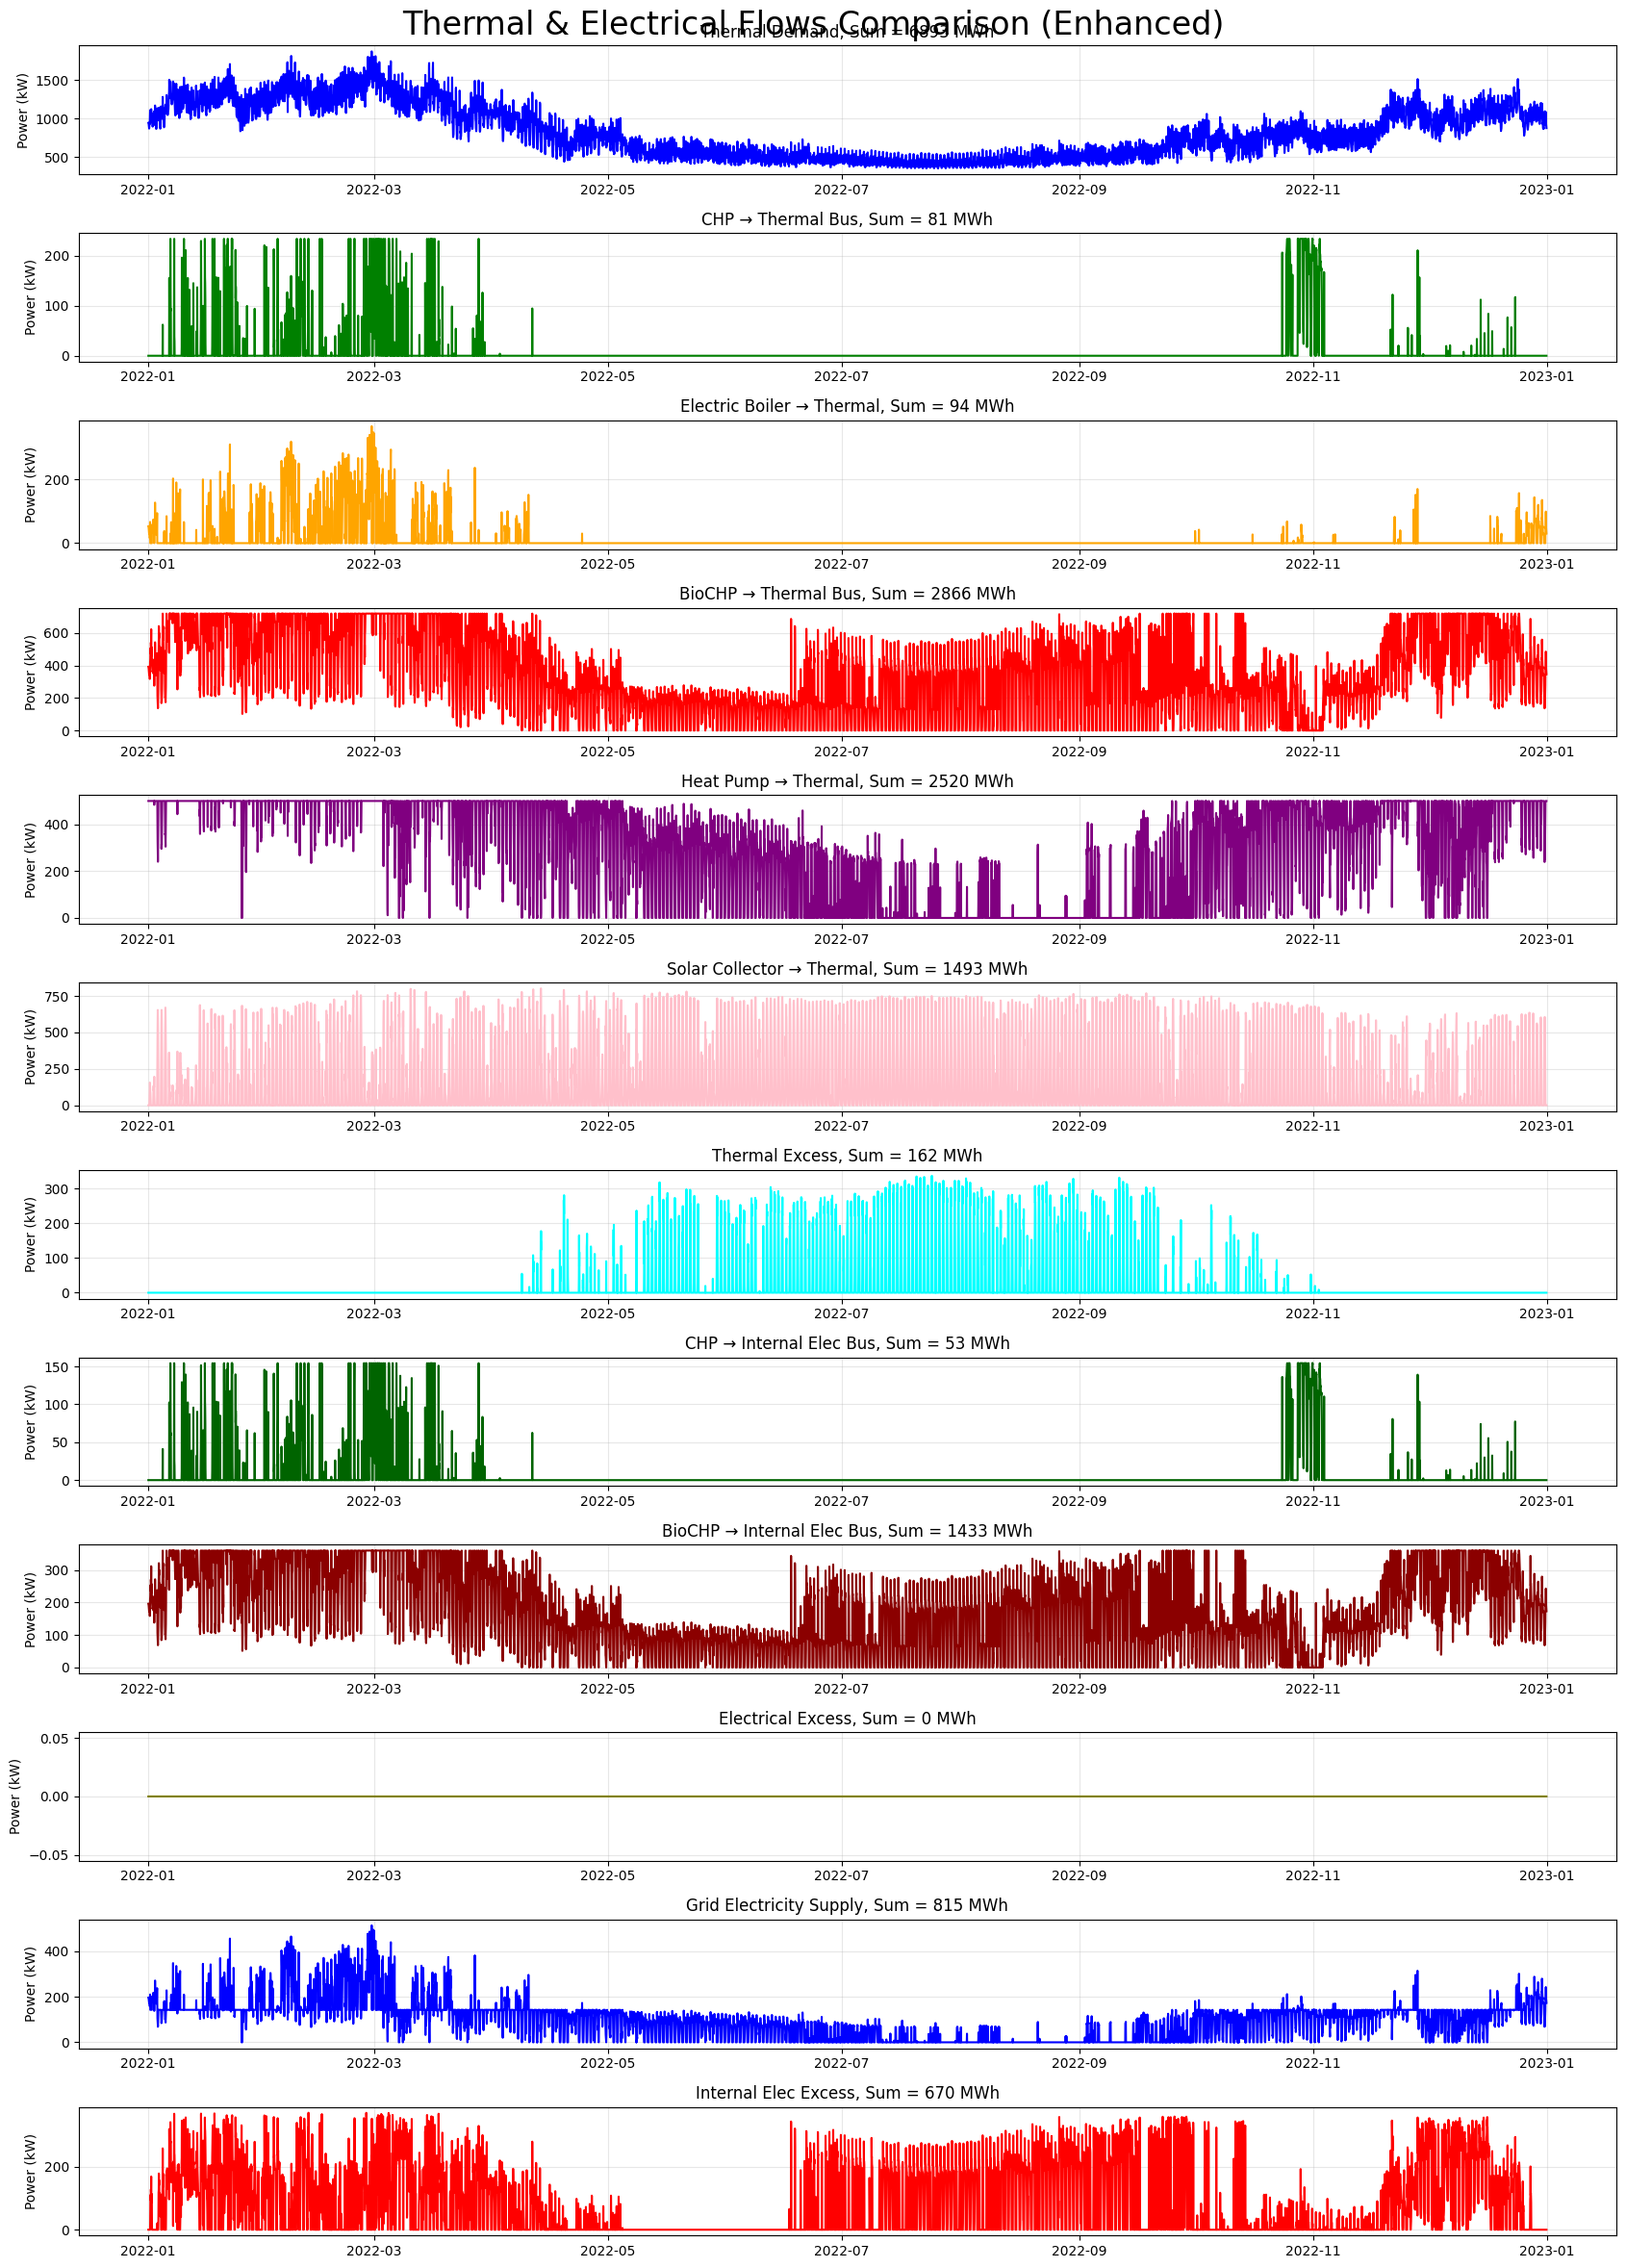

In [8]:
# Thermal sums (existing)
Sum_th_demand = thermal_results["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')].sum()
Sum_th_prod_chp = thermal_results["sequences"][(('chp', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_boiler = thermal_results["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_biochp = thermal_results["sequences"][(('biomass_chp', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp = thermal_results["sequences"][(('heat_pump', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_sth = thermal_results["sequences"][(('solar_collector', 'thermal_bus'), 'flow')].sum()
Sum_th_excess = thermal_results["sequences"][(('thermal_bus','excess_thermal'), 'flow')].sum()

# Electrical sums (existing + NEW electrical outputs from CHP/BioCHP)
Sum_excess_elec = electrical_results["sequences"][(('electrical_bus', 'excess_electricity'), 'flow')].sum()
Sum_el_grid_prod = electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')].sum()
Sum_el_excess_int = internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')].sum()

# NEW: CHP electrical production to internal bus
Sum_el_prod_chp = internal_elec_results["sequences"][(('chp', 'internal_elec_bus'), 'flow')].sum()
# NEW: Biomass CHP electrical production to internal bus
Sum_el_prod_biochp = internal_elec_results["sequences"][(('biomass_chp', 'internal_elec_bus'), 'flow')].sum()

# Updated 12-subplot figure
fig, axs = plt.subplots(12, 1, figsize=(17, 24))
fig.suptitle('Thermal & Electrical Flows Comparison (Enhanced)', fontsize=24)

# Thermal flows (0-6, unchanged)
axs[0].plot(thermal_results["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')], 'blue')
axs[0].set_title(f'Thermal Demand, Sum = {int(Sum_th_demand/1000)} MWh')

axs[1].plot(thermal_results["sequences"][(('chp', 'thermal_bus'), 'flow')], 'green')
axs[1].set_title(f'CHP → Thermal Bus, Sum = {int(Sum_th_prod_chp/1000)} MWh')

axs[2].plot(thermal_results["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')], 'orange')
axs[2].set_title(f'Electric Boiler → Thermal, Sum = {int(Sum_th_prod_boiler/1000)} MWh')

axs[3].plot(thermal_results["sequences"][(('biomass_chp', 'thermal_bus'), 'flow')], 'red')
axs[3].set_title(f'BioCHP → Thermal Bus, Sum = {int(Sum_th_prod_biochp/1000)} MWh')

axs[4].plot(thermal_results["sequences"][(('heat_pump', 'thermal_bus'), 'flow')], 'purple')
axs[4].set_title(f'Heat Pump → Thermal, Sum = {int(Sum_th_prod_hp/1000)} MWh')

axs[5].plot(thermal_results["sequences"][(('solar_collector', 'thermal_bus'), 'flow')], 'pink')
axs[5].set_title(f'Solar Collector → Thermal, Sum = {int(Sum_th_prod_sth/1000)} MWh')

axs[6].plot(thermal_results["sequences"][(('thermal_bus','excess_thermal'), 'flow')], 'cyan')
axs[6].set_title(f'Thermal Excess, Sum = {int(Sum_th_excess/1000)} MWh')

axs[7].plot(internal_elec_results["sequences"][(('chp', 'internal_elec_bus'), 'flow')], 'darkgreen')
axs[7].set_title(f'CHP → Internal Elec Bus, Sum = {int(Sum_el_prod_chp/1000)} MWh')

axs[8].plot(internal_elec_results["sequences"][(('biomass_chp', 'internal_elec_bus'), 'flow')], 'darkred')
axs[8].set_title(f'BioCHP → Internal Elec Bus, Sum = {int(Sum_el_prod_biochp/1000)} MWh')

axs[9].plot(electrical_results["sequences"][(('electrical_bus', 'excess_electricity'), 'flow')], 'olive')
axs[9].set_title(f'Electrical Excess, Sum = {int(Sum_excess_elec/1000)} MWh')

axs[10].plot(electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')], 'blue')
axs[10].set_title(f'Grid Electricity Supply, Sum = {int(Sum_el_grid_prod/1000)} MWh')

axs[11].plot(internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')], 'red')
axs[11].set_title(f'Internal Elec Excess, Sum = {int(Sum_el_excess_int/1000)} MWh')

# Format all subplots
for ax in axs:
    ax.set_ylabel('Power (kW)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Generating an Excel file for future analysis

In [9]:
grid_supply = electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')]
internal_excess = internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')]

# Per-timestep view of grid supply vs internal excess with difference
flows_comparison = pd.DataFrame(
    {
        'Grid Electricity Supply (kW)': grid_supply.values,
        'Internal Electricity Excess (kW)': internal_excess.values,
    },
    index=grid_supply.index,
)
flows_comparison['Grid minus Internal (kW)'] = (
    flows_comparison['Grid Electricity Supply (kW)']
    - flows_comparison['Internal Electricity Excess (kW)']
)

flows_comparison.to_excel('Outputs/electricity_flows_comparison.xlsx', 
                          sheet_name='Grid_vs_Internal', 
                          index=True)


## Answers to the questions

 ### How does including distribution losses change the operation of each generating unit?


Generation Share

In [10]:
# Load STEP_3 results (without losses)
step3_df = pd.read_csv("Outputs/STEP_3_results.csv", index_col=0, parse_dates=True)

# Extract STEP_3 totals
def get_step3_total(col_name):
    if col_name in step3_df.columns:
        return step3_df[col_name].sum() / 1000  # Convert to MWh
    return 0

step3_totals = {
    "NG CHP": 80.935,
    "Biomass CHP": 2848.869,
    "Heat pump": 2513.684,
    "Electric boiler": 94.063,
    "Solar collector": get_step3_total("solar_collector_thermal_bus_flow"),
}

# Extract STEP_4 totals (with losses)
step4_totals = {
    "NG CHP": thermal_results["sequences"][(("chp", "thermal_bus"), "flow")].sum() / 1000,
    "Biomass CHP": thermal_results["sequences"][(("biomass_chp", "thermal_bus"), "flow")].sum() / 1000,
    "Heat pump": thermal_results["sequences"][(("heat_pump", "thermal_bus"), "flow")].sum() / 1000,
    "Electric boiler": thermal_results["sequences"][(("electric_boiler", "thermal_bus"), "flow")].sum() / 1000,
    "Solar collector": thermal_results["sequences"][(("solar_collector", "thermal_bus"), "flow")].sum() / 1000,
}

# Comparison
comparison = pd.DataFrame({
    "STEP_3 (MWh)": step3_totals,
    "STEP_4 (MWh)": step4_totals,
})
comparison["Absolute variation (MWh)"] = comparison["STEP_4 (MWh)"] - comparison["STEP_3 (MWh)"]
comparison["Relative variation (%)"] = (comparison["Absolute variation (MWh)"] / comparison["STEP_3 (MWh)"] * 100).round(2)

print(comparison.sort_values("Absolute variation (MWh)", key=abs, ascending=False))
print("")

# Generation Share
print("----- Generation Share -------")
total = sum(step4_totals.values())
table_data = []
for tech, prod in step4_totals.items():
    perc = (prod / total * 100) if total > 0 else 0
    table_data.append([tech, f"{prod:.2f}", f"{perc:.2f}%"])

table_data

                 STEP_3 (MWh)  STEP_4 (MWh)  Absolute variation (MWh)  \
Biomass CHP       2848.869000   2866.092317                 17.223317   
Heat pump         2513.684000   2520.562999                  6.878999   
Electric boiler     94.063000     94.846314                  0.783314   
NG CHP              80.935000     81.014040                  0.079040   
Solar collector   1493.790612   1493.790612                  0.000000   

                 Relative variation (%)  
Biomass CHP                        0.60  
Heat pump                          0.27  
Electric boiler                    0.83  
NG CHP                             0.10  
Solar collector                    0.00  

----- Generation Share -------


[['NG CHP', '81.01', '1.15%'],
 ['Biomass CHP', '2866.09', '40.62%'],
 ['Heat pump', '2520.56', '35.72%'],
 ['Electric boiler', '94.85', '1.34%'],
 ['Solar collector', '1493.79', '21.17%']]

### Do any units now operate closer to their capacity limits?

In [11]:
# Extract investment capacities from optimization results (same method as STEP_3)
from oemof.solph import processing

res = processing.results(model)
res_str = processing.convert_keys_to_strings(res)

def get_invest_capacity(label_from, label_to="thermal_bus"):
    flow = res_str[(label_from, label_to)]
    scal = flow["scalars"]
    invest_row = scal[scal.index.to_series().str.contains("invest")]
    invest_value = float(invest_row.iloc[0])   # kW_th
    return invest_value

# Extract actual installed capacities from optimization results
heat_pump_cap = get_invest_capacity("heat_pump")
electric_boiler_cap = get_invest_capacity("electric_boiler")
biomass_chp_cap = get_invest_capacity("biomass_chp")
ng_chp_cap = get_invest_capacity("chp")



# Thermal nominal capacities (kW) - calculated from optimization results
nominal_caps = {
    "Heat pump": heat_pump_cap,
    "Electric boiler": electric_boiler_cap,
    "Biomass CHP": biomass_chp_cap,
    "NG CHP": ng_chp_cap,
    "Solar collector": nominal_value,
}

step3_cols = {
    "Biomass Chp": 717.46,
    "Chp": 234.55,
    "Heat Pump": 500,
    "Electric Boiler": 366.97,
    "Solar Collector": 802.93
}

# Mapping to sequence keys (STEP_4)
seq_keys = {
    "Heat pump": (("heat_pump", "thermal_bus"), "flow"),
    "Electric boiler": (("electric_boiler", "thermal_bus"), "flow"),
    "Biomass CHP": (("biomass_chp", "thermal_bus"), "flow"),
    "NG CHP": (("chp", "thermal_bus"), "flow"),
    "Solar collector": (("solar_collector", "thermal_bus"), "flow"),
}

# Mapping to STEP_3 column names
step3_cols = {
    "Heat pump": "heat_pump_thermal_bus_flow",
    "Electric boiler": "electric_boiler_thermal_bus_flow",
    "Biomass CHP": "biomass_chp_thermal_bus_flow",
    "NG CHP": "chp_thermal_bus_flow",
    "Solar collector": "solar_collector_thermal_bus_flow",
}

# STEP 3 hours at max capacity
manual_step3 = {
    "Heat pump": 2825,
    "Electric boiler": 1,
    "Biomass CHP": 1066,
    "NG CHP": 117,
    "Solar collector": 1
}


# Calculate hours at capacity for both steps
tolerance = 1
comparison = []
for unit, cap in nominal_caps.items():
    # STEP_4
    s4 = thermal_results["sequences"][seq_keys[unit]]
    hours_at_cap_4 = len(s4[s4 >= cap - tolerance])
    
    # STEP_3 
    hours_at_cap_3 = manual_step3[unit]  

    comparison.append({
        "Unit": unit,
        "STEP_3": hours_at_cap_3,
        "STEP_4": hours_at_cap_4,
        "Change": hours_at_cap_4 - hours_at_cap_3,
    })

comp_df = pd.DataFrame(comparison).sort_values("Change", ascending=False, key=abs)

print("Hours at capacity limit:")
print(comp_df.to_string(index=False))

closer_units = comp_df[comp_df["Change"] > 0]
if not closer_units.empty:
    print("\nUnits operating closer to capacity in STEP_4:")
    for _, row in closer_units.iterrows():
        print(f"  {row['Unit']}: +{int(row['Change'])} hours ({int(row['STEP_3'])} → {int(row['STEP_4'])})")
else:
    print("\nNo units operate closer to capacity in STEP_4.")



Hours at capacity limit:
           Unit  STEP_3  STEP_4  Change
      Heat pump    2825    2859      34
         NG CHP     117     122       5
    Biomass CHP    1066    1068       2
Electric boiler       1       1       0
Solar collector       1       1       0

Units operating closer to capacity in STEP_4:
  Heat pump: +34 hours (2825 → 2859)
  NG CHP: +5 hours (117 → 122)
  Biomass CHP: +2 hours (1066 → 1068)


### How are system efficiency, operating cost, and total heat generation affected?

In [12]:
# System efficiency analysis
total_heat_3 = sum(step3_totals.values())
total_heat_4 = sum(step4_totals.values())
heat_demand_3 = step3_df["thermal_bus_thermal_demand_flow"].sum() / 1000  # MWh (original demand without losses)
heat_demand_4 = Sum_th_demand / 1000  # MWh (original demand without losses)
efficiency_3 = (heat_demand_3 / total_heat_3 * 100)
efficiency_4 = (heat_demand_4 / total_heat_4 * 100)

summary = pd.DataFrame({
    "Metric": ["Total heat generation (MWh)", "Heat demand (MWh)", "System efficiency (%)"],
    "STEP_3": [f"{total_heat_3:.1f}", f"{heat_demand_3:.1f}", f"{efficiency_3:.1f}"],
    "STEP_4": [f"{total_heat_4:.1f}", f"{heat_demand_4:.1f}", f"{efficiency_4:.1f}"],
    "Change": [
        f"{total_heat_4 - total_heat_3:+.1f} ({((total_heat_4/total_heat_3 - 1)*100):+.1f}%)",
        f"{heat_demand_4 - heat_demand_3:+.1f} ({((heat_demand_4/heat_demand_3 - 1)*100):+.1f}%)",
        f"{efficiency_4 - efficiency_3:+.1f} pp"
    ]
})

print("System Efficiency Comparison (STEP_3 vs STEP_4):")
print(summary.to_string(index=False))



System Efficiency Comparison (STEP_3 vs STEP_4):
                     Metric STEP_3 STEP_4        Change
Total heat generation (MWh) 7031.3 7056.3 +25.0 (+0.4%)
          Heat demand (MWh) 6865.5 6893.6 +28.2 (+0.4%)
      System efficiency (%)   97.6   97.7       +0.1 pp


### Operating costs comparison

In [13]:
# STEP_4 - Fuel + O&M 
# Cost series (€/kWh)
gas_cost = data["gas_price"] / 1000
biomass_cost = (data["biomass_price"] / 4.167) / 1000
elec_price = data["electricity_price"] / 1000

# STEP_4 fuel costs
biomass_bus_res = views.node(results, "biomass_bus")
gas_bus_res = views.node(results, "gas_bus")
flow_gas_4 = gas_bus_res["sequences"][(("gas_bus", "chp"), "flow")]
flow_biomass_4 = biomass_bus_res["sequences"][(("biomass_bus", "biomass_chp"), "flow")]
net_grid_4 = flows_comparison["Grid minus Internal (kW)"].clip(lower=0)
price_elec_4 = pd.Series(elec_price.values, index=net_grid_4.index)

fuel_costs_4 = {
    "NG CHP (fuel)": (flow_gas_4 * gas_cost.values).sum(),
    "Biomass CHP (fuel)": (flow_biomass_4 * biomass_cost.values).sum(),
    "Grid electricity": (net_grid_4 * price_elec_4).sum(),
    "Heat pump": 0.0, "Electric boiler": 0.0, "Solar collector": 0.0,
}

# STEP_4 O&M costs
components = ["biomass_chp", "chp", "heat_pump", "electric_boiler", "solar_collector"]
thermal_flows_4 = {}
for comp in components:
    try:
        thermal_flow = views.node(results, comp)["sequences"][((comp, "thermal_bus"), "flow")]
        thermal_flows_4[comp] = thermal_flow
    except KeyError:
        thermal_flows_4[comp] = pd.Series(0.0, index=net_grid_4.index)

om_costs_4 = {}
for comp in components:
    flow_kwh = thermal_flows_4[comp].sum()
    om_rate = om_variable_costs[comp]
    om_costs_4[comp.replace("_", " ").title()] = flow_kwh * om_rate

# Total OPEX
fuel_to_om = {
    "NG CHP (fuel)": "Chp", "Biomass CHP (fuel)": "Biomass Chp", 
    "Grid electricity": None, "Heat pump": "Heat Pump",
    "Electric boiler": "Electric Boiler", "Solar collector": "Solar Collector"
}
total_opex_4 = {}
for tech in fuel_costs_4.keys():
    om_key = fuel_to_om[tech]
    total_opex_4[tech] = fuel_costs_4[tech] + om_costs_4.get(om_key, 0.0)



In [14]:
# STEP_4 - OPEX visualization
units = list(total_opex_4.keys())
step4_df = pd.DataFrame({
    "Unit": units + ["TOTAL"],
    "Fuel (EUR)": [f"{fuel_costs_4[unit]:,.0f}" for unit in units] + [f"{sum(fuel_costs_4.values()):,.0f}"],
    "O&M (EUR)": [f"{om_costs_4.get(fuel_to_om[unit], 0):,.0f}" for unit in units] + [f"{sum(om_costs_4.values()):,.0f}"],
    "Total OPEX (EUR)": [f"{total_opex_4[unit]:,.0f}" for unit in units] + [f"{sum(total_opex_4.values()):,.0f}"]
})
print("STEP_4 Operating Costs:")
print("="*50)
print(step4_df.to_string(index=False))


STEP_4 Operating Costs:
              Unit Fuel (EUR) O&M (EUR) Total OPEX (EUR)
     NG CHP (fuel)     12,868     1,434           14,302
Biomass CHP (fuel)    247,611    25,151          272,762
  Grid electricity     84,876         0           84,876
         Heat pump          0     6,042            6,042
   Electric boiler          0        27               27
   Solar collector          0       768              768
             TOTAL    345,354    33,423          378,777


Compared to Step 3, the OPEX increased by around 1678 € per year, which is a 0.4% increase. Most of it comes from the Biomass CHP, which increased +1639€.

### Investment cost comparison

In [15]:
# CAPEX STEP_4 
capex_kw_th = {
    "biomass_chp": 2200, "chp": 1200, "heat_pump": 1400, 
    "electric_boiler": 250, "solar_collector": 300 
}

# STEP_4 capacities
from oemof.solph import processing
res4 = processing.results(model)
res_str4 = processing.convert_keys_to_strings(res4)

def get_invest_capacity(res_str, label_from, label_to="thermal_bus"):
    try:
        flow = res_str[(label_from, label_to)]
        scal = flow["scalars"]
        invest_row = scal[scal.index.to_series().str.contains("invest")]
        return float(invest_row.iloc[0])
    except:
        return 0.0

capacities_4 = {}
for comp in capex_kw_th.keys():
    cap = get_invest_capacity(res_str4, comp)
    capacities_4[comp.replace("_", " ").title()] = cap

capacities_4["Solar Collector"] = 802.1

# CAPEX calculations STEP_4
capex_4 = {k: v * capex_kw_th[k.lower().replace(" ", "_")] for k, v in capacities_4.items()}

# STEP_4 DataFrame
units = list(capacities_4.keys())
step4_df = pd.DataFrame({
    "Technology": units + ["TOTAL"],
    "Capacity (kW_th)": [f"{capacities_4[unit]:.1f}" for unit in units] + [""],
    "CAPEX (€)": [f"{capex_4[unit]:,.0f}" for unit in units] + [f"{sum(capex_4.values()):,.0f}"]
})

print("CAPEX STEP_4 - Capacity and Investment Costs:")
print("="*50)
print(step4_df.to_string(index=False))

print(f"\nSUMMARY STEP_4:")
print(f"TOTAL CAPEX: {sum(capex_4.values()):,.0f} €")


CAPEX STEP_4 - Capacity and Investment Costs:
     Technology Capacity (kW_th) CAPEX (€)
    Biomass Chp            720.3 1,584,605
            Chp            233.9   280,734
      Heat Pump            500.0   700,000
Electric Boiler            368.0    91,992
Solar Collector            802.1   240,630
          TOTAL                  2,897,960

SUMMARY STEP_4:
TOTAL CAPEX: 2,897,960 €


Compared to Step 3, the total CAPEX increased by just above 5000€, which is a 0.18% increase. Again here, the increase comes from the Biomass CHP increase of capacity. We can notice that the Gas CHP decreases the cost by 300€, compensated with an increase of the electric boiler by 260€. 

## Exporting results for Step 5

In [16]:
# Export STEP_4 results to CSV for use in STEP_5
from pathlib import Path
import shutil

# Create Outputs directory if it doesn't exist
output_dir = Path("Outputs")
output_dir.mkdir(exist_ok=True)

# Extract key flows for export (same structure as Scenario A)
step4_results = {}

# Gas flows
gas_bus_res = views.node(results, "gas_bus")
step4_results["gas_bus_chp_flow"] = gas_bus_res["sequences"][(("gas_bus", "chp"), "flow")]

# Biomass flows
biomass_bus_res = views.node(results, "biomass_bus")
step4_results["biomass_bus_biomass_chp_flow"] = biomass_bus_res["sequences"][(("biomass_bus", "biomass_chp"), "flow")]

# Grid electricity flows
grid_src_res = views.node(results, "electricity_grid")
step4_results["electricity_grid_electrical_bus_flow"] = grid_src_res["sequences"][(("electricity_grid", "electrical_bus"), "flow")]

# Thermal flows
step4_results["chp_thermal_bus_flow"] = thermal_results["sequences"][(("chp", "thermal_bus"), "flow")]
step4_results["biomass_chp_thermal_bus_flow"] = thermal_results["sequences"][(("biomass_chp", "thermal_bus"), "flow")]
step4_results["heat_pump_thermal_bus_flow"] = thermal_results["sequences"][(("heat_pump", "thermal_bus"), "flow")]
step4_results["electric_boiler_thermal_bus_flow"] = thermal_results["sequences"][(("electric_boiler", "thermal_bus"), "flow")]
step4_results["solar_collector_thermal_bus_flow"] = thermal_results["sequences"][(("solar_collector", "thermal_bus"), "flow")]

# Create DataFrame
step4_df_export = pd.DataFrame(step4_results, index=thermal_results["sequences"].index)

# Export to local Outputs folder
local_output_file = output_dir / "STEP_4_results.csv"
step4_df_export.to_csv(local_output_file)
print(f"✓ STEP_4 results exported to: {local_output_file}")

# Also export to STEP_5/Outputs folder for easy access
step5_output_dir = Path("..") / "STEP_5" / "Outputs"
if step5_output_dir.exists():
    step5_output_file = step5_output_dir / "STEP_4_results.csv"
    step4_df_export.to_csv(step5_output_file)
    print(f"STEP_4 results also exported to: {step5_output_file}")
else:
    print(f"STEP_5/Outputs directory not found. Tried: {step5_output_dir}")
    print("  Results are available in local Outputs folder only.")

print(f"\nTotal rows: {len(step4_df_export)}")
print(f"Columns: {list(step4_df_export.columns)}")

✓ STEP_4 results exported to: Outputs\STEP_4_results.csv
STEP_4 results also exported to: ..\STEP_5\Outputs\STEP_4_results.csv

Total rows: 8760
Columns: ['gas_bus_chp_flow', 'biomass_bus_biomass_chp_flow', 'electricity_grid_electrical_bus_flow', 'chp_thermal_bus_flow', 'biomass_chp_thermal_bus_flow', 'heat_pump_thermal_bus_flow', 'electric_boiler_thermal_bus_flow', 'solar_collector_thermal_bus_flow']
